### Questions the visualizations answer
* Do models overestimate or underestimate correctness scores?
* What corruption types are the hardest to predict the correctness score?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    font="sans-serif",
    font_scale=1.0,
    rc={
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.titlesize": 9,
    },
)

In [2]:
HEAD_DIR = Path.cwd().parent.parent.parent / "models" / "correctness_heads"

FAMILIES   = ["ad_lstm_wl_delta", "ad_xgb_wl_delta",
              "dd_lstm_shortest_path_delta", "dd_xgb_wl_delta"]
SEEDS      = [13, 23, 37]
TEST_SPLITS = ["test-interpolation", "test-extrapolation"]
SPLIT_LABELS = {"test-interpolation": "Test Interpolation",
                "test-extrapolation": "Test Extrapolation"}

In [3]:
rows = []
for family in FAMILIES:
    for seed in SEEDS:
        path = HEAD_DIR / family / f"exp_final" / f"seed_{seed}" / "predictions.csv"
        df = pd.read_csv(path)
        df["family"] = family
        df["seed"]   = seed
        rows.append(df)

preds = pd.concat(rows, ignore_index=True)

In [4]:
preds[preds["split"] == "train"].groupby("corruption_type").size().sort_values()

corruption_type
insert       180
delete      2652
swap        2712
replace     2772
truncate    2772
gold        2784
dtype: int64

In [5]:
df = preds[preds["split"].isin(TEST_SPLITS)].copy()
df["split_label"] = df["split"].map(SPLIT_LABELS)

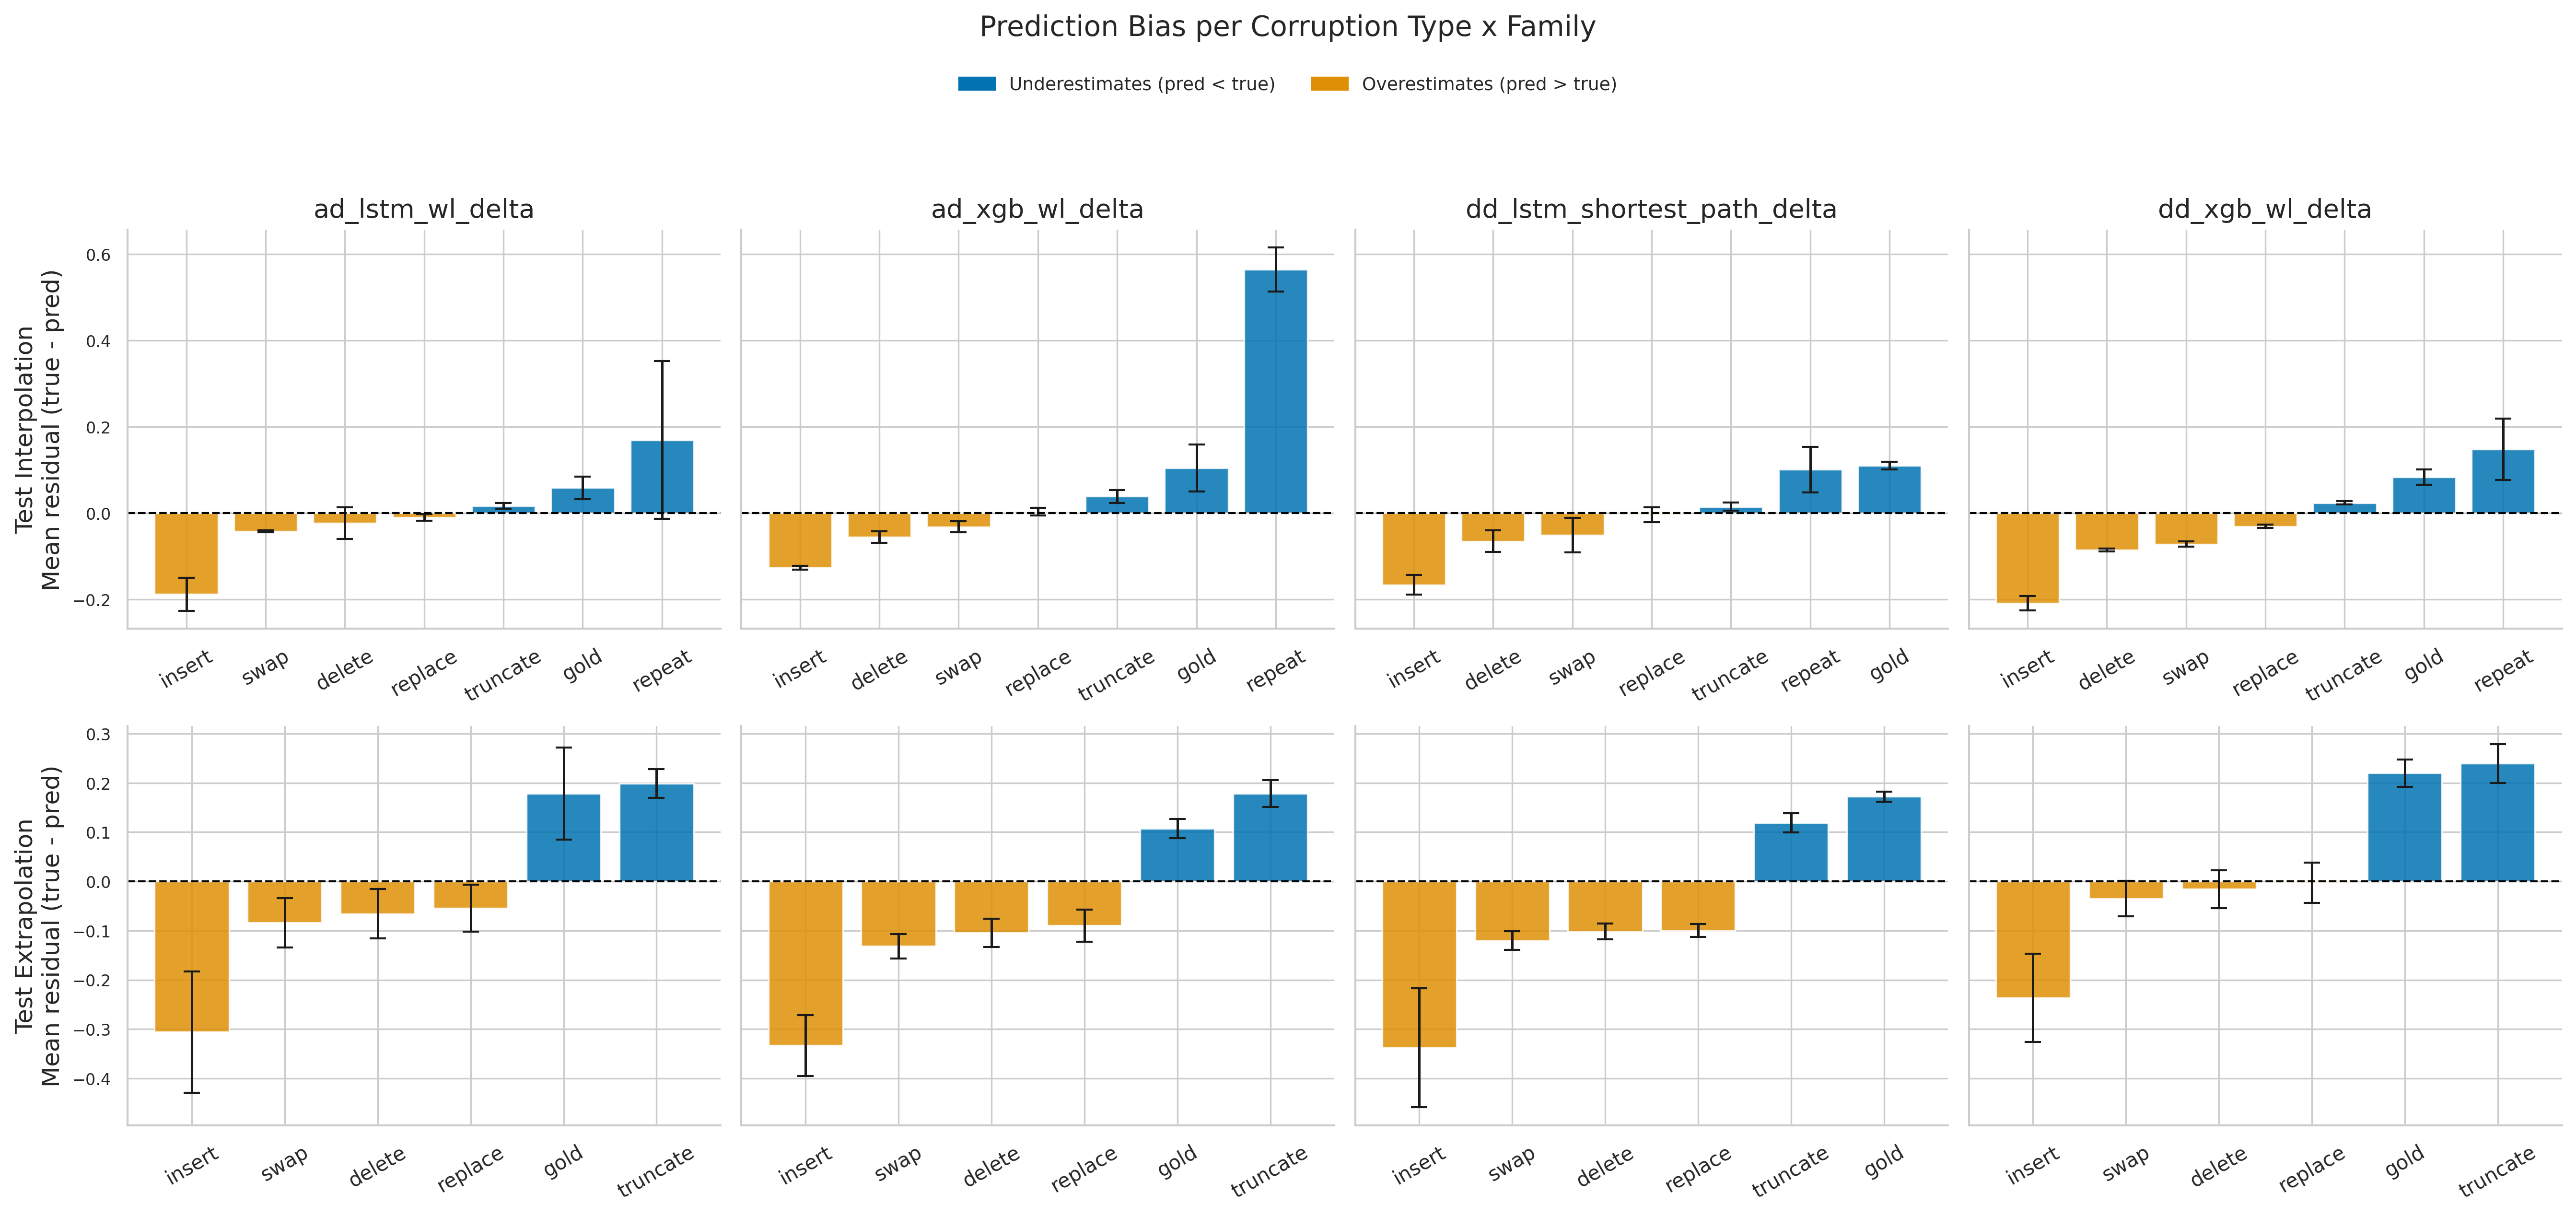

In [6]:
# mean residual per (family, split, corruption_type, seed)
seed_means = (
    df.groupby(["family", "split", "corruption_type", "seed"])["residual"]
    .mean()
    .reset_index(name="mean_residual_seed")
)

# mean and std across the 3 seeds, keeping family separate
agg = (
    seed_means
    .groupby(["family", "split", "corruption_type"])["mean_residual_seed"]
    .agg(mean_residual="mean", std_residual="std")
    .reset_index()
)
agg["split_label"] = agg["split"].map(SPLIT_LABELS)

from matplotlib.patches import Patch

palette = sns.color_palette("colorblind", 2)
splits_ordered = [SPLIT_LABELS[s] for s in TEST_SPLITS]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey="row")

for row_i, split_label in enumerate(splits_ordered):
    for col_i, family in enumerate(FAMILIES):
        ax = axes[row_i, col_i]
        sub = (
            agg[(agg["split_label"] == split_label) & (agg["family"] == family)]
            .sort_values("mean_residual")
        )
        colors = [palette[0] if v > 0 else palette[1] for v in sub["mean_residual"]]

        ax.bar(
            sub["corruption_type"],
            sub["mean_residual"],
            yerr=sub["std_residual"],
            capsize=4,
            color=colors,
            alpha=0.85,
        )
        ax.axhline(0, color="black", linewidth=1.0, linestyle="--")

        if row_i == 0:
            ax.set_title(family, fontsize=13)
        if col_i == 0:
            ax.set_ylabel(f"{split_label}\nMean residual (true - pred)", fontsize=12)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="x", rotation=30, labelsize=10)
        ax.tick_params(axis="y", labelsize=8)

legend_handles = [
    Patch(color=palette[0], label="Underestimates (pred < true)"),
    Patch(color=palette[1], label="Overestimates (pred > true)"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
    fontsize=9,
)
fig.suptitle("Prediction Bias per Corruption Type x Family", fontsize=14, y=1.05)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("bias_by_corruption.png", bbox_inches="tight")
plt.show()

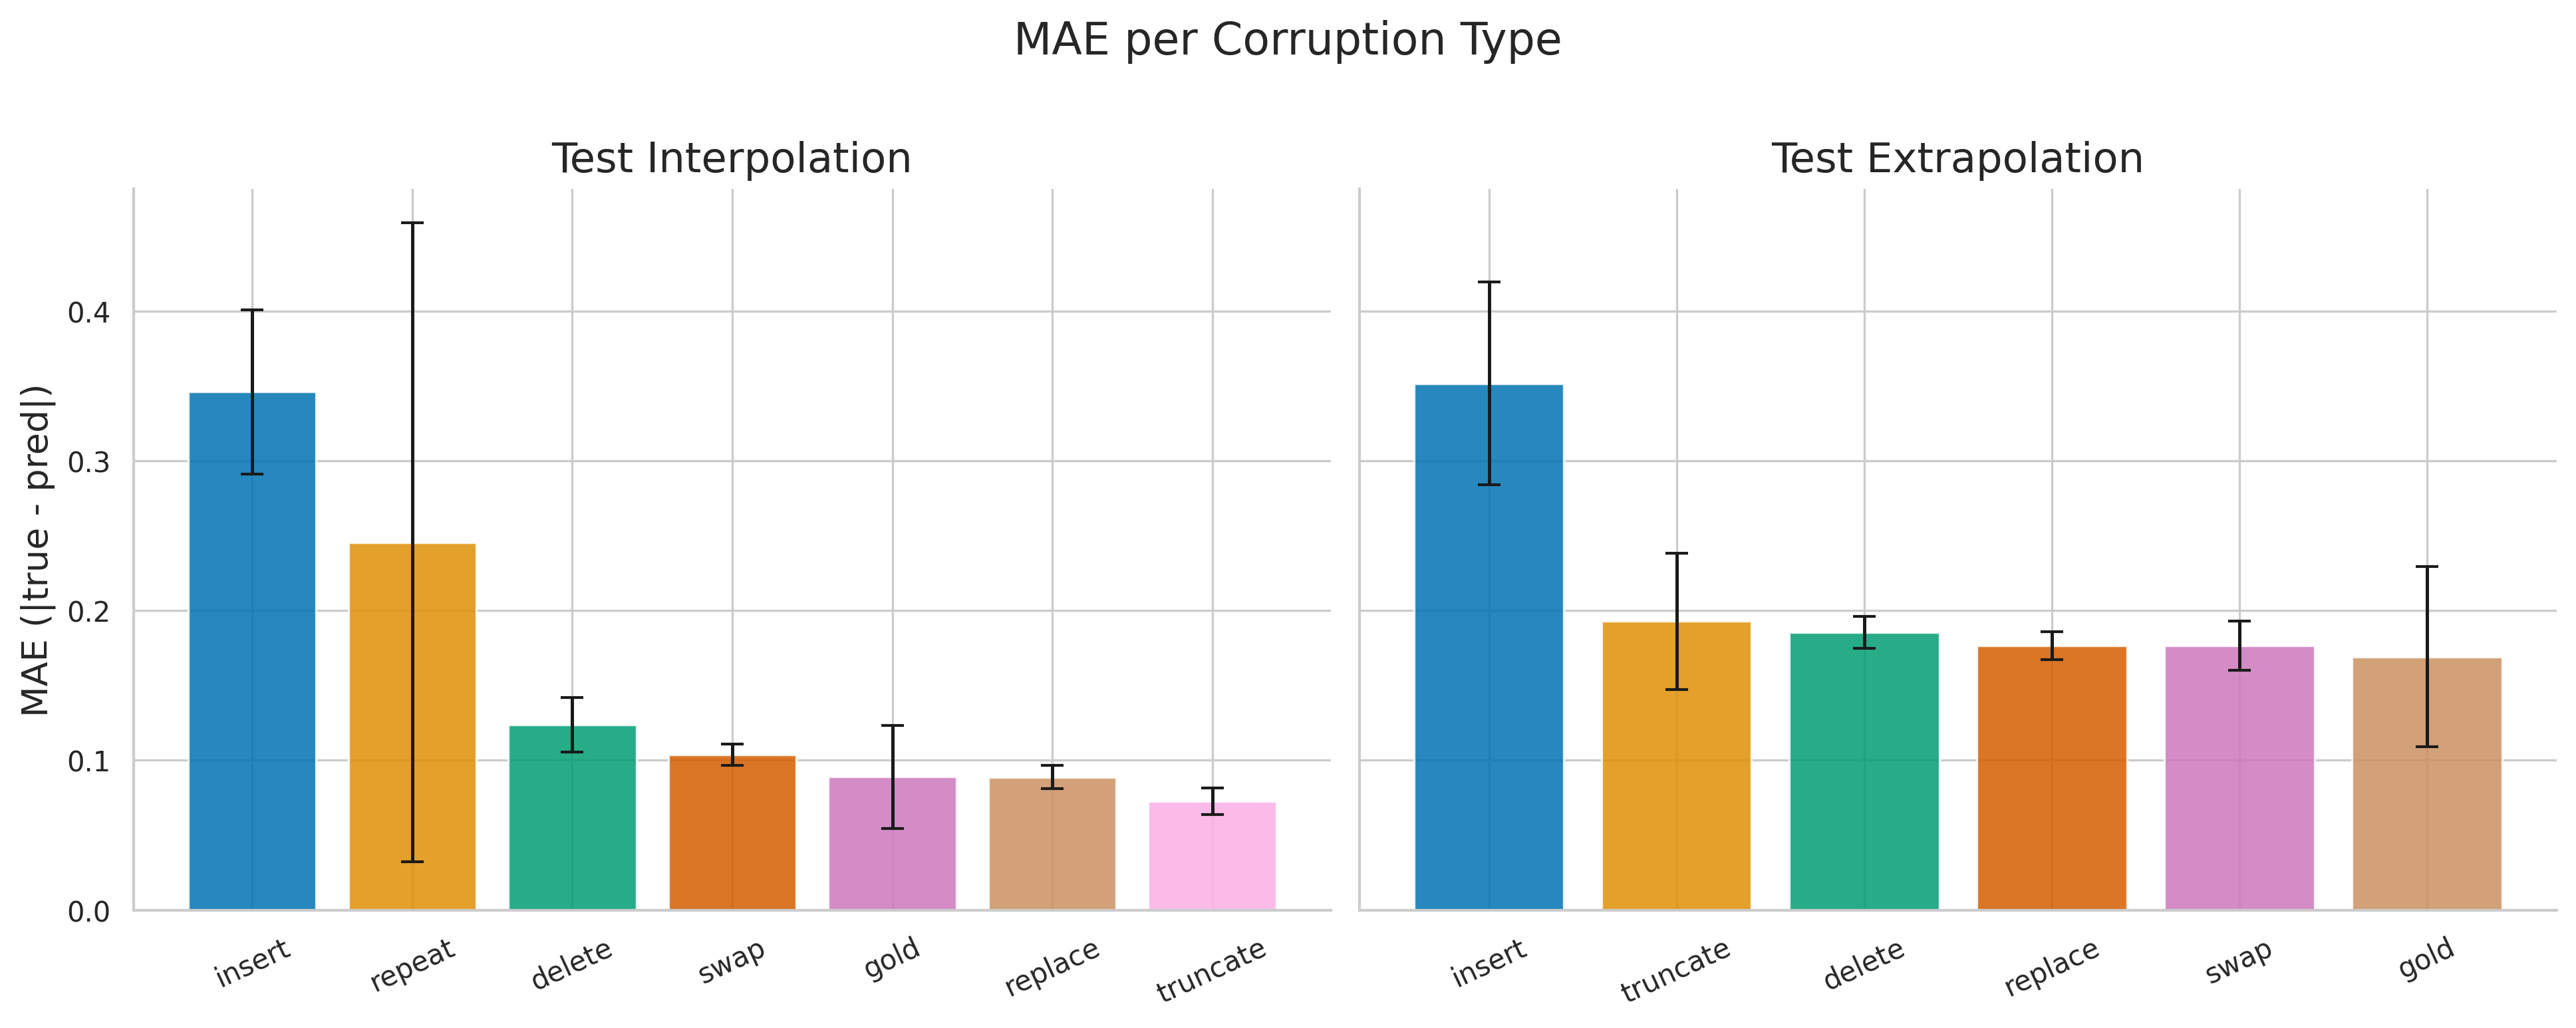

In [7]:
df["abs_residual"] = df["residual"].abs()

seed_means = (
    df.groupby(["family", "split", "corruption_type", "seed"])["abs_residual"]
    .mean()
    .reset_index(name="mae_seed")
)

agg = (
    seed_means
    .groupby(["split", "corruption_type"])["mae_seed"]
    .agg(mean_mae="mean", std_mae="std")
    .reset_index()
)
agg["split_label"] = agg["split"].map(SPLIT_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
colors = sns.color_palette(n_colors=len(agg["corruption_type"].unique()))

for i, (ax, split_label) in enumerate(zip(axes, [SPLIT_LABELS[s] for s in TEST_SPLITS])):
    sub = agg[agg["split_label"] == split_label].sort_values("mean_mae", ascending=False)

    ax.bar(
        sub["corruption_type"],
        sub["mean_mae"],
        yerr=sub["std_mae"],
        capsize=4,
        color=colors,
        alpha=0.85,
    )

    ax.set_title(split_label, fontsize=15)

    if i == 0:
        ax.set_ylabel("MAE (|true - pred|)", fontsize=13)
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="x", rotation=25, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

fig.suptitle("MAE per Corruption Type", fontsize=16, y=1.02)

fig.tight_layout()

plt.savefig("mae_by_corruption_type.png", bbox_inches="tight")
plt.show()